In [1]:
import math
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
comments=pd.read_csv("UScomments.csv",
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False)

videos=pd.read_csv("USvideos.csv",
    on_bad_lines='skip',
    encoding='utf-8')

<h3>Coments dataset </h3> 

In [4]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524298 entries, 0 to 524297
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      524298 non-null  object
 1   comment_text  524282 non-null  object
 2   likes         524297 non-null  object
 3   replies       524297 non-null  object
dtypes: object(4)
memory usage: 16.0+ MB


<h5>Change of the number of the column likes a likes_comment to not confuse with the likes of the video </h5>

In [6]:
comments=comments.rename(columns={'likes': 'likes_comment'})

In [7]:
comments.sample(3)

,video_id,comment_text,likes_comment,replies
96390,7bdZn5MKugo,i love the fact you still buying affordable op...,0,0
31398,7nh2Ra-5kY8,That was beautiful sportsmanship! Congrats.,0,0
3928,O78Lpo4ctSE,very unique... simply the best...,0,0


<h5>Change the type of data in the column likes how to return it</h5>

In [9]:
comments['likes_comment'] = pd.to_numeric(comments['likes_comment'],errors='coerce')
comments['replies'] = pd.to_numeric(comments['replies'],errors='coerce')

In [10]:
comments.info()
comments.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524298 entries, 0 to 524297
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   video_id       524298 non-null  object 
 1   comment_text   524282 non-null  object 
 2   likes_comment  524296 non-null  float64
 3   replies        524296 non-null  float64
dtypes: float64(2), object(2)
memory usage: 16.0+ MB


,video_id,comment_text,likes_comment,replies
141767,cWfTBkTJOH8,1:49 woah those bubbled soo big,0.0,0.0
395199,ZyHipL45pwM,Snarky puppy!,0.0,0.0
469515,ufE-HaySXSg,BIGGEST BULLSHIT EVER,0.0,0.0


<h5>Rows with null values ​​are checked and deleted</h5>

In [12]:
comments.isna().sum()

video_id          0
comment_text     16
likes_comment     2
replies           2
dtype: int64

In [13]:
comments = comments.dropna(axis='rows').reset_index(drop=True)

In [14]:
comments.isna().sum()

video_id         0
comment_text     0
likes_comment    0
replies          0
dtype: int64

In [15]:
comments.sample(3)

,video_id,comment_text,likes_comment,replies
296696,l7yxJDFvTRM,*Technology*,0.0,0.0
472140,Mp_u8KvKg9I,Awesome show John !,0.0,0.0
522490,2jvi4e0NIHs,"MORE Halloween!!! YES! I'm so here for them, y...",0.0,0.0


<h3>Videos dataset </h3> 

In [17]:
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7992 non-null   object 
 1   title           7992 non-null   object 
 2   channel_title   7992 non-null   object 
 3   category_id     7992 non-null   int64  
 4   tags            7992 non-null   object 
 5   views           7992 non-null   int64  
 6   likes           7992 non-null   int64  
 7   dislikes        7992 non-null   int64  
 8   comment_total   7992 non-null   int64  
 9   thumbnail_link  7992 non-null   object 
 10  date            7992 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 686.9+ KB


<h5>Change of the number of the column likes a likes_video to not confuse with the likes of the comment </h5>

In [19]:
videos=videos.rename(columns={'likes': 'likes_video'})

In [20]:
videos.sample(3)

,video_id,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date
6381,ucWPplMZnH4,MAKING RIHANNA'S CLOTHES *for cheap!*,Amber Scholl,26,rihanna|diy|cheap|boots|make|dupe|celebrity|lo...,455746,22682,823,2407,https://i.ytimg.com/vi/ucWPplMZnH4/default.jpg,14.1
3843,Ri4xPHGS5f8,O.J. Simpson walks out of prison after release,CNN,25,oj simpson|simposn|o.j. simpson|paul vercammen...,34131,235,108,545,https://i.ytimg.com/vi/Ri4xPHGS5f8/default.jpg,2.1
5406,KbYCmEptlL8,Blindfolded Makeup Challenge | Jordyn Does Kyl...,Kylie Cosmetics,22,Kylie Jenner|Jordyn Woods|Kylie Cosmetics|Make...,728736,39810,1135,1884,https://i.ytimg.com/vi/KbYCmEptlL8/default.jpg,10.1


<h5>The date column is only formatted dd:mm, a default year (2025) was added to be able to change the data type and perform temporal analysis.</h5>

In [22]:
videos['date'] = videos['date'].astype(str) + '.2025'
videos['date'] = pd.to_datetime(videos['date'], format='%d.%m.%Y')

videos['year'] = videos['date'].dt.year
videos['month'] = videos['date'].dt.month
videos['day'] = videos['date'].dt.day

In [23]:
videos.sample(3)

,video_id,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day
2794,kIssu4XLg00,SOME THINGS I SHOULD TELL YOU // Grace Helbig,Grace Helbig,22,itsgrace|funny|comedy|vlog|grace|helbig|graceh...,236898,11872,309,619,https://i.ytimg.com/vi/kIssu4XLg00/default.jpg,2025-09-26,2025,9,26
3163,ao21eJgsF1w,iPhone 8 vs Samsung Galaxy S8 Salt Water Test!,TechRax,24,iphone|durability|samsung|galaxy|s8|water|dama...,1481639,21605,4467,4335,https://i.ytimg.com/vi/ao21eJgsF1w/default.jpg,2025-09-28,2025,9,28
1373,CzYM4ZpSDJg,Adam Ruins Everything - The Messed-Up Story of...,truTV,24,“truTv|Shows”|”truTV|New|Series”|episode|clips...,472460,8544,466,1135,https://i.ytimg.com/vi/CzYM4ZpSDJg/default.jpg,2025-09-19,2025,9,19


In [24]:
videos.isna().sum()

video_id          0
title             0
channel_title     0
category_id       0
tags              0
views             0
likes_video       0
dislikes          0
comment_total     0
thumbnail_link    0
date              0
year              0
month             0
day               0
dtype: int64

<h3>Merged Dataset df</h3>

<h5>The two datasets are combined using videos_id as a common column.</h5>

In [27]:
df = pd.merge(comments, videos, on='video_id')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196666 entries, 0 to 2196665
Data columns (total 17 columns):
 #   Column          Dtype         
---  ------          -----         
 0   video_id        object        
 1   comment_text    object        
 2   likes_comment   float64       
 3   replies         float64       
 4   title           object        
 5   channel_title   object        
 6   category_id     int64         
 7   tags            object        
 8   views           int64         
 9   likes_video     int64         
 10  dislikes        int64         
 11  comment_total   int64         
 12  thumbnail_link  object        
 13  date            datetime64[ns]
 14  year            int32         
 15  month           int32         
 16  day             int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(5), object(6)
memory usage: 259.8+ MB


In [29]:
df.sample(3)

,video_id,comment_text,likes_comment,replies,title,channel_title,category_id,tags,views,likes_video,dislikes,comment_total,thumbnail_link,date,year,month,day
920997,uA4STm4hx7Q,Christmas in September,1.0,0.0,Gwen Stefani - You Make It Feel Like Christmas...,GwenStefaniVEVO,10,Gwen|Stefani|You|Make|It|Feel|Like|Christmas|I...,129005,4162,197,533,https://i.ytimg.com/vi/uA4STm4hx7Q/default.jpg,2025-09-25,2025,9,25
1327477,mC1qPDqV6hM,I'm just too skeptical about Google launching ...,0.0,0.0,Google Ultra Pixel - New Pixel 2 Smartphone LE...,Mrwhosetheboss,28,google ultra pixel|google pixel 2|google pixel...,478819,9261,1031,1314,https://i.ytimg.com/vi/mC1qPDqV6hM/default.jpg,2025-01-01,2025,1,1
681032,-wQLKMUWANg,"Well, if you want to talk numbers, then microb...",0.0,0.0,The Age of Giant Insects,PBS Eons,28,dinosaurs|dinos|paleo|paleontology|scishow|eon...,116695,5099,118,588,https://i.ytimg.com/vi/-wQLKMUWANg/default.jpg,2025-09-22,2025,9,22


<h3>EDA</h3>

<h5>Videos were analyzed by day since the dataset only contains two months (January and September)</h5>

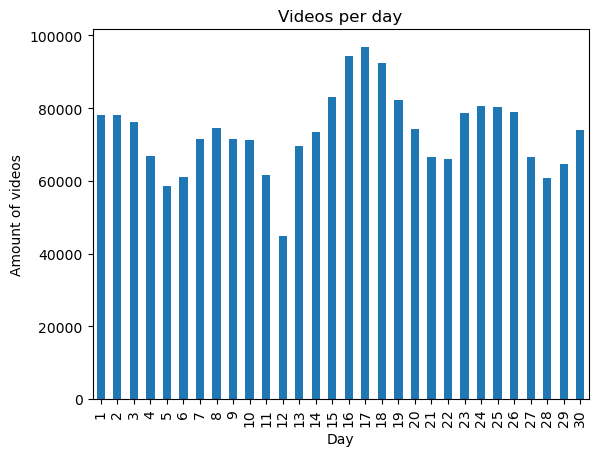

In [32]:
df['day'].value_counts().sort_index().plot(kind='bar', title='Videos per day')
plt.xlabel('Day')
plt.ylabel('Amount of videos')
plt.show()


<h5>Top comments with the most likes</h5>

In [34]:
top_comentarios = df.sort_values(by='likes_comment', ascending=False).head(10)
display(top_comentarios[['comment_text', 'likes_comment', 'video_id']])

,comment_text,likes_comment,video_id
593236,What if Mable was the duck??,48772.0,0R7MQwmbiQc
593237,What if Mable was the duck??,48772.0,0R7MQwmbiQc
593238,What if Mable was the duck??,48772.0,0R7MQwmbiQc
593239,What if Mable was the duck??,48772.0,0R7MQwmbiQc
592840,What if Mable was the duck??,47785.0,0R7MQwmbiQc
592841,What if Mable was the duck??,47785.0,0R7MQwmbiQc
592842,What if Mable was the duck??,47785.0,0R7MQwmbiQc
592843,What if Mable was the duck??,47785.0,0R7MQwmbiQc
592441,What if Mable was the duck??,45316.0,0R7MQwmbiQc
592443,What if Mable was the duck??,45316.0,0R7MQwmbiQc


<h5>Top videos with the most likes</h5>

In [36]:
top_comments_video = df.sort_values(by='likes_video', ascending=False).head(10)
display(top_comments_video[['comment_text', 'likes_video', 'video_id']])

,comment_text,likes_video,video_id
580330,BRASIL,2010366,MBdVXkSdhwU
580286,38M,2010366,MBdVXkSdhwU
579934,Perfect as expected💓,2010366,MBdVXkSdhwU
580602,Guys help me where can i dwnload their album?,2010366,MBdVXkSdhwU
579798,I really love this boys! Can't stop listening ...,2010366,MBdVXkSdhwU
579486,Perfect 👌 👏,2010366,MBdVXkSdhwU
580138,PH ARMIESSSSSSSS LET US SCREAM AND CRY TOGETHE...,2010366,MBdVXkSdhwU
580606,I like it again and again,2010366,MBdVXkSdhwU
580414,"40,000,000 let's go",2010366,MBdVXkSdhwU
580270,Streaming to 40million fighting!!!,2010366,MBdVXkSdhwU


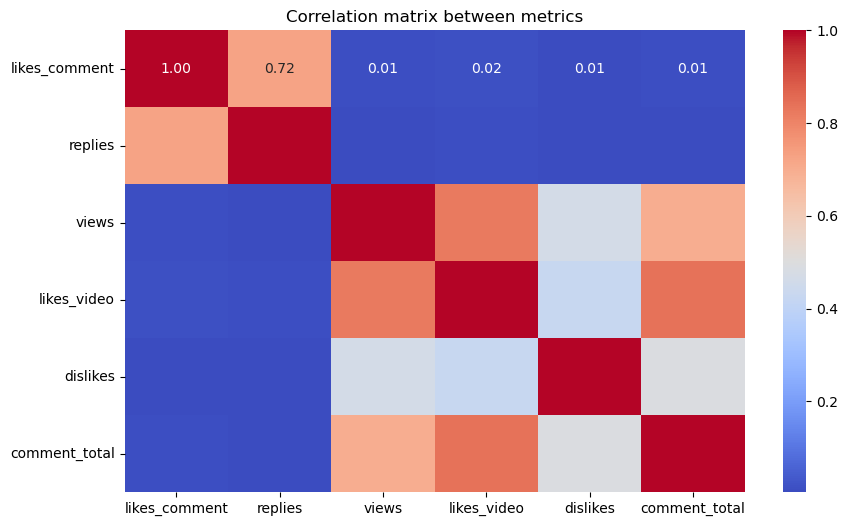

In [37]:
num_cols = ['likes_comment', 'replies', 'views', 'likes_video', 'dislikes', 'comment_total']
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix between metrics')
plt.show()

<li>There is a particularly strong correlation between "comment_likes" and "replies" (0.72), suggesting that comments with many "likes" tend to generate more replies.</li>

<li>The correlations with "views" are very low (0.01), indicating that the number of views is not strongly related to comment likes.</li>

<li>Comment engagement (likes and replies) is correlated.</li>



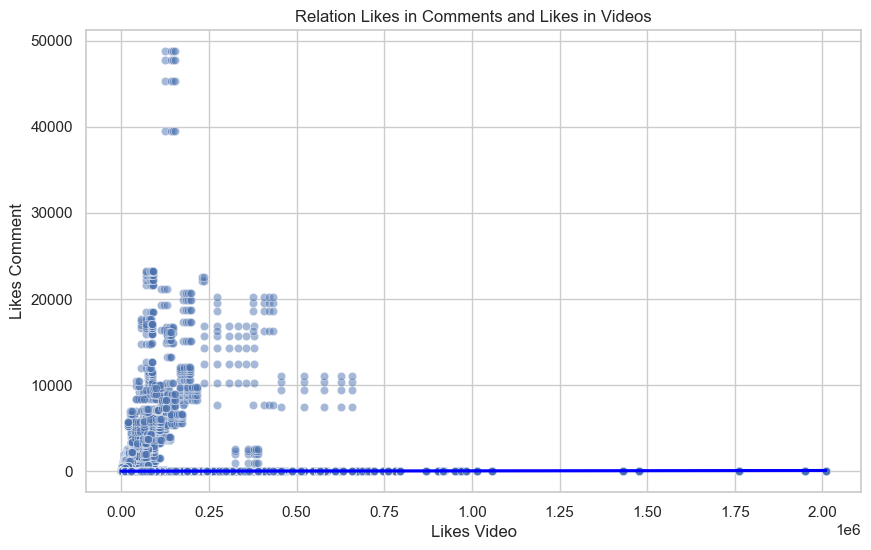

In [39]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
scatter1 = sns.scatterplot(data=df, x='likes_video', y='likes_comment', alpha=0.5)
sns.regplot(df, x='likes_video', y='likes_comment', scatter=False, color='blue')
plt.title('Relation Likes in Comments and Likes in Videos')
plt.xlabel('Likes Video')
plt.ylabel('Likes Comment')
plt.show()

<li>Low ratios (around 1) suggest videos with similar numbers of likes and dislikes, indicating content that generates mixed opinions.</li>

<li> The few videos with high ratios (>50) represent content with almost exclusively likes and very few dislike</li>>

C:\Users\laura\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


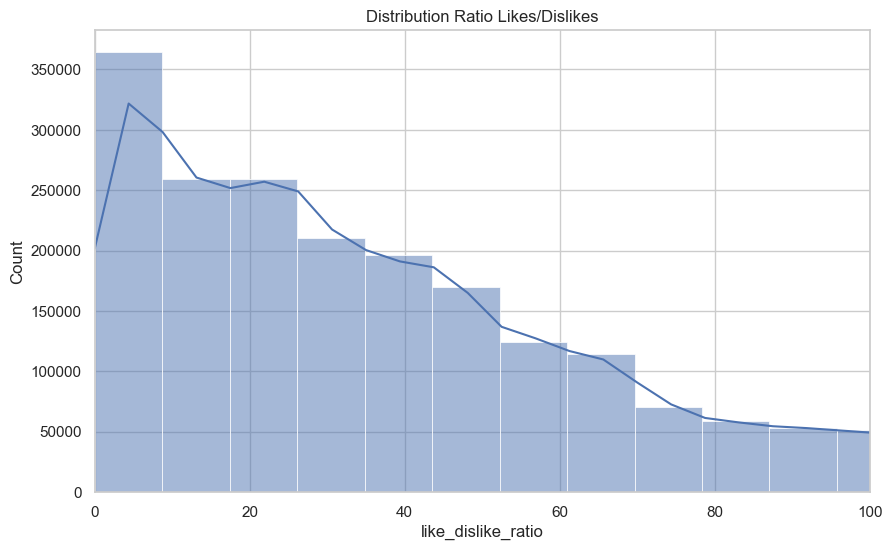

In [41]:
# ratio
df['like_dislike_ratio'] = df['likes_video'] / (df['dislikes'] + 1)  

plt.figure(figsize=(10, 6))
sns.histplot(df['like_dislike_ratio'], bins=100, kde=True)
plt.xlim(0, 100)  
plt.title('Distribution Ratio Likes/Dislikes')
plt.show()

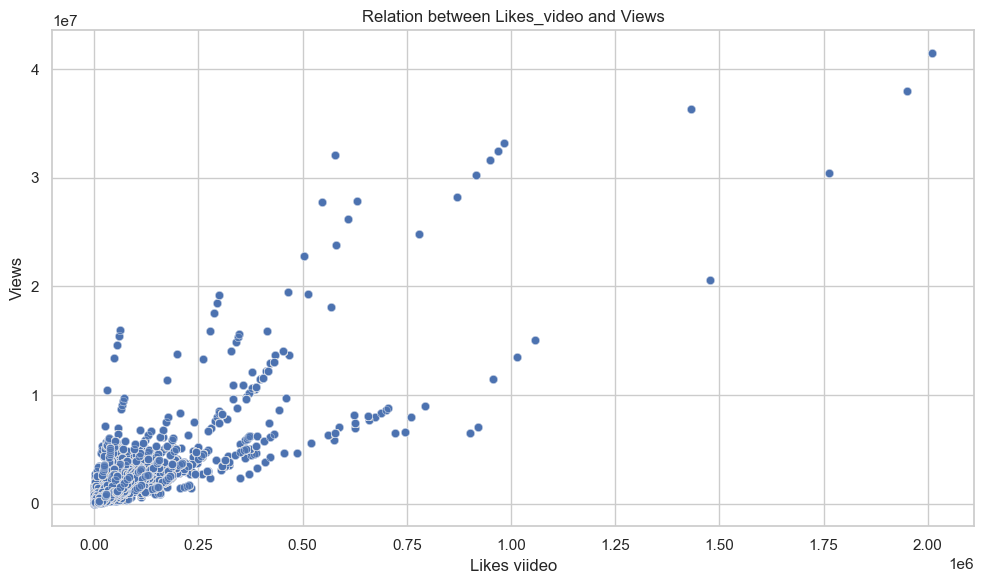

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='likes_video', y='views', alpha=0.3)

plt.title('Relation between Likes_video and Views')
plt.xlabel('Likes viideo')
plt.ylabel('Views')
plt.grid(True)
plt.tight_layout()
plt.show()

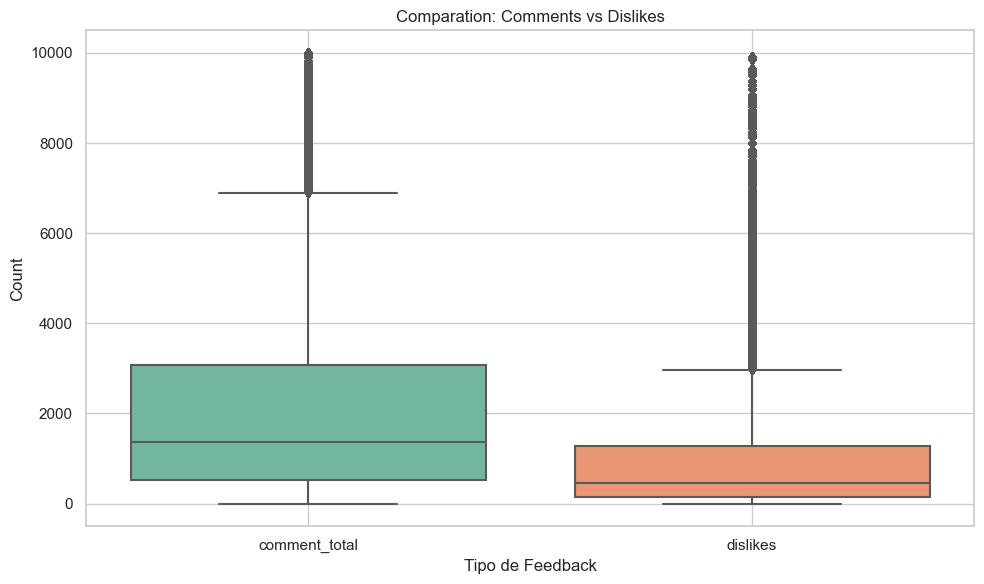

In [76]:
# Crear un DataFrame nuevo para comparación
df_melted = pd.melt(df, value_vars=['comment_total', 'dislikes'], 
                    var_name='Tipo de Feedback', value_name='Cantidad')

# Filtrar para eliminar valores extremos que distorsionen la vista
df_melted = df_melted[df_melted['Cantidad'] < 10000]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Tipo de Feedback', y='Cantidad', palette='Set2')

plt.title('Comparation: Comments vs Dislikes')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

<h3>Machine learning for text</h3>